# Modelo de estimación de probabilidad de incumplimiento

In [100]:
from pathlib import Path

data_dir = Path().resolve().parent / "data" / "aprobados-negados"

In [101]:
import pandas as pd

file_path = data_dir / "merged_df.csv"
df = pd.read_csv(
    file_path,
    sep=";",
    )
df.head(5)

,Unnamed: 0,n.credito,cartera,plazo,vinculacion,v.cuota,v.prestamo,s.capital,s.intereses,aportes,...,curtotalingresos,curtotalegresos,intestrato,actualización,default,puntaje_data,grupo_dptmto,grupo_ciudad,grupo_edad,grupo_actividadeco
0,0,003-002-0125852-7,consumo_sin_libranza,1827,8103,356849.0,15000000.0,12923538.0,123855,7741255,...,4597000.0,1500000.0,5.0,1.0,0.0,795.0,3.0,1.0,3.0,4.0
1,1,004-002-0068475-5,consumo_sin_libranza,1826,1434,2650409.0,100460000.0,31911361.0,263265,4601706,...,4597000.0,650000.0,5.0,1.0,0.0,836.0,3.0,5.0,3.0,4.0
2,2,003-002-0122592-9,consumo_sin_libranza,1826,573,791482.0,30000000.0,23844684.0,261477,530431,...,4400000.0,2000000.0,4.0,0.0,1.0,709.0,3.0,7.0,2.0,4.0
3,3,006-002-0023879-0,consumo_sin_libranza,2922,1902,2860501.0,176000000.0,113842595.0,1008570,3023534,...,22020000.0,1500000.0,4.0,1.0,0.0,733.0,3.0,6.0,3.0,1.0
4,4,006-002-0026159-4,consumo_sin_libranza,2557,1902,987637.0,50300000.0,38521256.0,317167,1023082,...,22020000.0,1500000.0,4.0,1.0,0.0,695.0,3.0,6.0,3.0,1.0


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12861 entries, 0 to 12860
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          12861 non-null  int64  
 1   n.credito           12861 non-null  object 
 2   cartera             12861 non-null  object 
 3   plazo               12861 non-null  int64  
 4   vinculacion         12861 non-null  int64  
 5   v.cuota             12861 non-null  float64
 6   v.prestamo          12861 non-null  float64
 7   s.capital           12861 non-null  float64
 8   s.intereses         12861 non-null  int64  
 9   aportes             12861 non-null  int64  
 10  morosidad           12861 non-null  int64  
 11  garantias           12861 non-null  int64  
 12  valorgarantia       12861 non-null  int64  
 13  reestr              12861 non-null  int64  
 14  ctasahorros         12861 non-null  object 
 15  edad                12861 non-null  float64
 16  tipo

In [103]:
df = df[[
    'cartera', 
    'default', 
    'puntaje_data', 
    'intestrato', 
    'edad', 
    'grupo_edad', 
    'sexo',
    'curtotalingresos',
    'curtotalegresos',
    'grupo_actividadeco'
    ]]

df['dif_ingresos_egresos'] = df['curtotalingresos'] - df['curtotalegresos']
df['genero'] = df['sexo'].map({0.0: 'Masculino', 1.0: 'Femenino'})
df['default_label'] = df['default'].map({0: 'No default', 1: 'Default'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12861 entries, 0 to 12860
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cartera               12861 non-null  object 
 1   default               12857 non-null  float64
 2   puntaje_data          12857 non-null  float64
 3   intestrato            12857 non-null  float64
 4   edad                  12861 non-null  float64
 5   grupo_edad            12857 non-null  float64
 6   sexo                  12857 non-null  float64
 7   curtotalingresos      12857 non-null  float64
 8   curtotalegresos       12857 non-null  float64
 9   grupo_actividadeco    12857 non-null  float64
 10  dif_ingresos_egresos  12857 non-null  float64
 11  genero                12857 non-null  object 
 12  default_label         12857 non-null  object 
dtypes: float64(10), object(3)
memory usage: 1.3+ MB


In [104]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12857 entries, 0 to 12860
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cartera               12857 non-null  object 
 1   default               12857 non-null  float64
 2   puntaje_data          12857 non-null  float64
 3   intestrato            12857 non-null  float64
 4   edad                  12857 non-null  float64
 5   grupo_edad            12857 non-null  float64
 6   sexo                  12857 non-null  float64
 7   curtotalingresos      12857 non-null  float64
 8   curtotalegresos       12857 non-null  float64
 9   grupo_actividadeco    12857 non-null  float64
 10  dif_ingresos_egresos  12857 non-null  float64
 11  genero                12857 non-null  object 
 12  default_label         12857 non-null  object 
dtypes: float64(10), object(3)
memory usage: 1.4+ MB


In [105]:
df['cartera'].value_counts()

cartera
consumo_sin_libranza    7489
consumo_con_libranza    5368
Name: count, dtype: int64

In [106]:
df['default_label'].value_counts()

default_label
No default    10628
Default        2229
Name: count, dtype: int64

In [107]:
df['grupo_actividadeco'].value_counts()

grupo_actividadeco
4.0    11454
3.0      809
1.0      472
2.0      122
Name: count, dtype: int64

In [108]:
df['grupo_edad'].value_counts()

grupo_edad
2.0    7023
1.0    2891
3.0    2745
4.0     176
5.0      22
Name: count, dtype: int64

In [109]:
df['intestrato'].value_counts()

intestrato
3.0    5230
2.0    5084
1.0    1045
4.0    1013
5.0     349
6.0     135
0.0       1
Name: count, dtype: int64

In [110]:
df = df[df['intestrato'] != 0]
df['intestrato'].value_counts()

intestrato
3.0    5230
2.0    5084
1.0    1045
4.0    1013
5.0     349
6.0     135
Name: count, dtype: int64

In [111]:
df_sin_libranza = df[df['cartera'] == 'consumo_sin_libranza'].copy()
df_sin_libranza = df_sin_libranza.drop(columns=['cartera'])
df_con_libranza = df[df['cartera'] == 'consumo_con_libranza'].copy()
df_con_libranza = df_con_libranza.drop(columns=['cartera'])

## Sin libranza

In [112]:
df_sin_libranza.groupby('default_label')['puntaje_data'].describe()

,count,mean,std,min,25%,50%,75%,max
default_label,,,,,,,,
Default,2123.0,693.357042,103.168953,304.0,664.0,716.0,760.0,850.0
No default,5365.0,763.515750,72.162899,304.0,736.0,778.0,811.0,850.0


In [113]:
df_sin_libranza.groupby('default_label')['curtotalingresos'].describe()

,count,mean,std,min,25%,50%,75%,max
default_label,,,,,,,,
Default,2123.0,3.436934e+06,1.012226e+07,0.0,1044951.5,1420000.0,2500000.0,185000000.0
No default,5365.0,5.187873e+06,1.552938e+07,0.0,1577963.0,2500000.0,4500000.0,400000000.0


In [114]:
df_sin_libranza.groupby('default_label')['curtotalegresos'].describe()

,count,mean,std,min,25%,50%,75%,max
default_label,,,,,,,,
Default,2123.0,8.622715e+05,3.076264e+06,0.0,300000.0,500000.0,750000.0,1.240000e+08
No default,5365.0,1.417093e+06,2.056882e+07,0.0,400000.0,600000.0,1000000.0,1.501600e+09


In [115]:
df_sin_libranza.groupby('default_label')['dif_ingresos_egresos'].describe()

,count,mean,std,min,25%,50%,75%,max
default_label,,,,,,,,
Default,2123.0,2.574663e+06,8.598125e+06,-6.500000e+06,658516.0,959500.0,1751815.0,171451000.0
No default,5365.0,3.770780e+06,2.524525e+07,-1.491024e+09,1050000.0,1800000.0,3405740.0,395000000.0


In [116]:
(pd.crosstab(
    df_sin_libranza['default_label'], 
    df_sin_libranza['genero'], 
    normalize='columns', 
    margins=True, 
    margins_name='Total'
    ).round(3)) * 100

genero,Femenino,Masculino,Total
default_label,,,
Default,22.6,33.8,28.4
No default,77.4,66.2,71.6


In [117]:
(df_sin_libranza.pivot_table(
    index='default_label',
    columns='genero', 
    margins=True, 
    margins_name='Total',
    values='edad',
    aggfunc='count'
)/len(df_sin_libranza)).round(3) * 100

genero,Femenino,Masculino,Total
default_label,,,
Default,11.0,17.3,28.4
No default,37.6,34.0,71.6
Total,48.6,51.4,100.0


In [118]:
(pd.crosstab(
    df_sin_libranza['default_label'], 
    df_sin_libranza['grupo_edad'], 
    normalize='columns', 
    margins=True, 
    margins_name='Total'
    ).round(3)) * 100

grupo_edad,1.0,2.0,3.0,4.0,5.0,Total
default_label,,,,,,
Default,35.0,31.4,17.0,6.4,13.6,28.4
No default,65.0,68.6,83.0,93.6,86.4,71.6


In [119]:
(pd.crosstab(
    df_sin_libranza['default_label'], 
    df_sin_libranza['intestrato'], 
    normalize='columns', 
    margins=True, 
    margins_name='Total'
    ).round(3)) * 100

intestrato,1.0,2.0,3.0,4.0,5.0,6.0,Total
default_label,,,,,,,
Default,38.4,31.6,26.5,23.2,19.9,16.5,28.4
No default,61.6,68.4,73.5,76.8,80.1,83.5,71.6


In [120]:
(df_sin_libranza.pivot_table(
    index='default_label',
    columns='intestrato', 
    margins=True, 
    margins_name='Total',
    values='edad',
    aggfunc='count'
)/len(df_sin_libranza)).round(3) * 100

intestrato,1.0,2.0,3.0,4.0,5.0,6.0,Total
default_label,,,,,,,
Default,2.6,11.1,11.3,2.3,0.7,0.3,28.4
No default,4.2,24.1,31.5,7.7,2.9,1.3,71.6
Total,6.8,35.2,42.8,10.0,3.6,1.5,100.0


In [121]:
(df_sin_libranza.pivot_table(
    index='default_label',
    columns='intestrato', 
    margins=True, 
    margins_name='Total',
    values='curtotalingresos',
    aggfunc='median'
)/len(df_sin_libranza)).round(3) * 100

intestrato,1.0,2.0,3.0,4.0,5.0,6.0,Total
default_label,,,,,,,
Default,15665.1,16444.3,21367.5,53418.8,110053.0,227904.8,18963.7
No default,20865.4,26201.9,37393.2,62767.1,86805.6,177617.5,33386.8
Total,18055.6,22561.1,32689.6,60096.2,88127.2,177617.5,28715.4


In [122]:
(df_sin_libranza.pivot_table(
    index='default_label',
    columns='intestrato', 
    margins=True, 
    margins_name='Total',
    values='curtotalegresos',
    aggfunc='median'
)/len(df_sin_libranza)).round(3) * 100

intestrato,1.0,2.0,3.0,4.0,5.0,6.0,Total
default_label,,,,,,,
Default,5341.9,5341.9,6677.4,12139.4,21367.5,80128.2,6677.4
No default,6677.4,6677.4,8943.6,13354.7,24038.5,53418.8,8012.8
Total,6009.6,6677.4,8012.8,13354.7,24038.5,53418.8,8012.8


In [123]:
(df_sin_libranza.pivot_table(
    index='default_label',
    columns='intestrato', 
    margins=True, 
    margins_name='Total',
    values='dif_ingresos_egresos',
    aggfunc='median'
)/len(df_sin_libranza)).round(3) * 100

intestrato,1.0,2.0,3.0,4.0,5.0,6.0,Total
default_label,,,,,,,
Default,10471.9,10845.0,14484.5,33386.8,74118.6,111666.7,12813.8
No default,14022.4,18696.6,26709.4,43657.9,61538.8,130876.1,24038.5
Total,12687.0,15471.0,22990.8,41553.4,62500.9,124198.7,20032.1


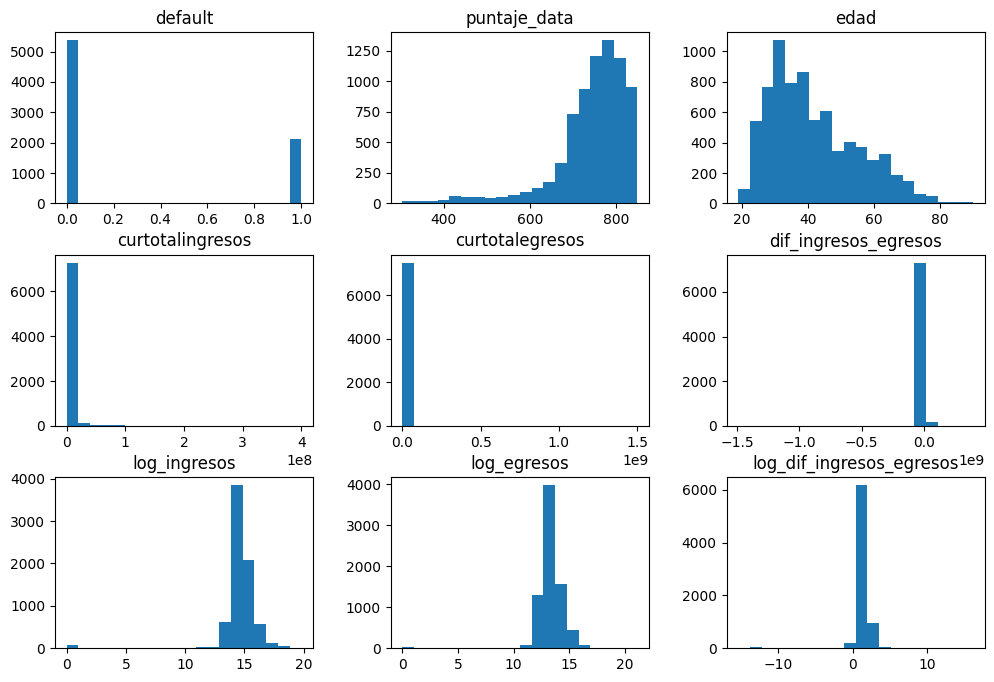

In [124]:
import numpy as np

df_sin_libranza['log_ingresos'] = np.log1p(df_sin_libranza['curtotalingresos'])
df_sin_libranza['log_egresos'] = np.log1p(df_sin_libranza['curtotalegresos'])
df_sin_libranza['log_dif_ingresos_egresos'] = df_sin_libranza['log_ingresos'] - df_sin_libranza['log_egresos']

df_sin_libranza.drop(
    columns=['sexo','grupo_edad', 'grupo_actividadeco', 'intestrato']
    ).hist(
        figsize=(12, 8),
        bins=20, 
        grid=False
        );

### Modelo

In [125]:
df_sin_libranza.head(5)

,default,puntaje_data,intestrato,edad,grupo_edad,sexo,curtotalingresos,curtotalegresos,grupo_actividadeco,dif_ingresos_egresos,genero,default_label,log_ingresos,log_egresos,log_dif_ingresos_egresos
0,0.0,795.0,5.0,59.0,3.0,0.0,4597000.0,1500000.0,4.0,3097000.0,Masculino,No default,15.340915,14.220976,1.119938
1,0.0,836.0,5.0,55.0,3.0,0.0,4597000.0,650000.0,4.0,3947000.0,Masculino,No default,15.340915,13.384729,1.956186
2,1.0,709.0,4.0,37.0,2.0,0.0,4400000.0,2000000.0,4.0,2400000.0,Masculino,Default,15.297115,14.508658,0.788457
3,0.0,733.0,4.0,66.0,3.0,0.0,22020000.0,1500000.0,1.0,20520000.0,Masculino,No default,16.907462,14.220976,2.686485
4,0.0,695.0,4.0,66.0,3.0,0.0,22020000.0,1500000.0,1.0,20520000.0,Masculino,No default,16.907462,14.220976,2.686485


In [133]:
from sklearn.model_selection import train_test_split

X = df_sin_libranza.drop(
    columns=[
        'default',
        'default_label',
        'genero',
        'log_ingresos',
        'log_egresos',
        'log_dif_ingresos_egresos'
        ]
    )
y = df_sin_libranza['default']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

print(X_train.shape)
print(X_test.shape)

(5990, 9)
(1498, 9)


In [135]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=1,
    class_weight='balanced'
    )

dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
print(classification_report(
    y_test, 
    y_pred,
    target_names=['No Default', 'Default']
    ))

              precision    recall  f1-score   support

  No Default       0.84      0.81      0.83      1073
     Default       0.56      0.62      0.59       425

    accuracy                           0.76      1498
   macro avg       0.70      0.71      0.71      1498
weighted avg       0.76      0.76      0.76      1498



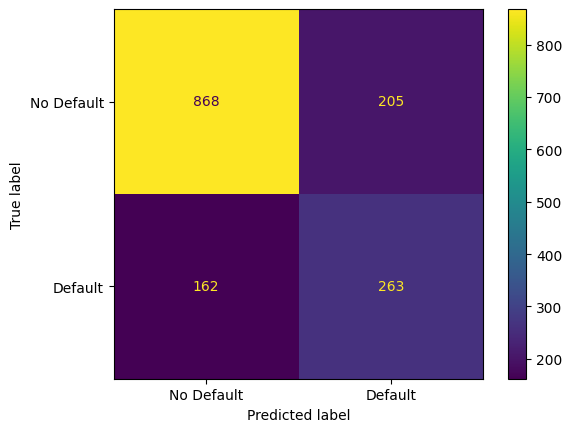

In [136]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    dt_model, 
    X_test, 
    y_test, 
    display_labels=['No Default', 'Default']
    );

In [139]:
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

dist = {
    'ccp_alpha': loguniform(1e-4, 1e-1),
    'class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}]
}

random_search = RandomizedSearchCV(
    dt_model,
    dist,
    scoring='f1',
    n_iter=50,
    random_state=1,
)

random_search.fit(X_train, y_train)

print(f"Best F1 score: {random_search.best_score_:.3f}\n")
print("Best hyperparameters:")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

Best F1 score: 0.610

Best hyperparameters:
ccp_alpha: 0.0007300053042915264
class_weight: balanced


In [141]:
print(f"Train score: {random_search.score(X_train, y_train):.3f}")
print(f"Test score: {random_search.score(X_test, y_test):.3f}")

y_pred = random_search.predict(X_test)
print(classification_report(
    y_test, 
    y_pred,
    target_names=['No Default', 'Default']
    ))

Train score: 0.636
Test score: 0.584
              precision    recall  f1-score   support

  No Default       0.84      0.81      0.83      1073
     Default       0.56      0.61      0.58       425

    accuracy                           0.75      1498
   macro avg       0.70      0.71      0.70      1498
weighted avg       0.76      0.75      0.76      1498



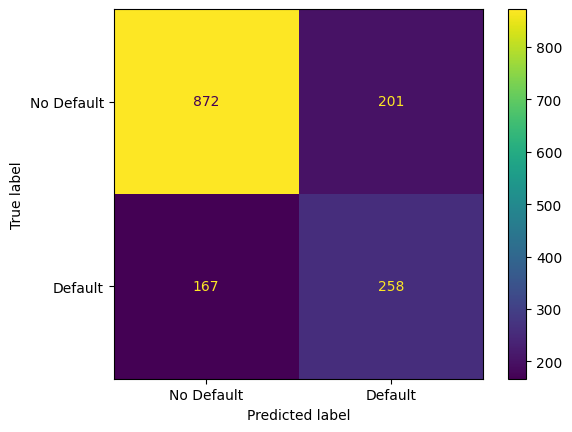

In [142]:
ConfusionMatrixDisplay.from_estimator(
    random_search, 
    X_test, 
    y_test, 
    display_labels=['No Default', 'Default']
    );

In [148]:
# Encontrar el umbral que maximice el F1 score
from sklearn.metrics import f1_score

y_proba_train = random_search.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.0, 1.01, 0.01)
f1_scores = [f1_score(y_train, y_proba_train >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.3f}")

Best threshold: 0.470


In [149]:
# Métrica de Entrenamiento aplicando el umbral calibrado
y_train_pred = (y_proba_train >= best_threshold).astype(int)
train_score = f1_score(y_train, y_train_pred, pos_label=1)

# Métrica de Prueba Definitiva aplicando el umbral calibrado
y_proba_test = random_search.predict_proba(X_test)[:, 1]
y_test_pred = (y_proba_test >= best_threshold).astype(int)
test_score = f1_score(y_test, y_test_pred, pos_label=1)

print(f"Métrica de Entrenamiento (F1-Score Clase Yes): {train_score:.3f}")
print(f"Métrica de Prueba Definitiva (F1-Score Clase Yes): {test_score:.3f}")

Métrica de Entrenamiento (F1-Score Clase Yes): 0.636
Métrica de Prueba Definitiva (F1-Score Clase Yes): 0.584


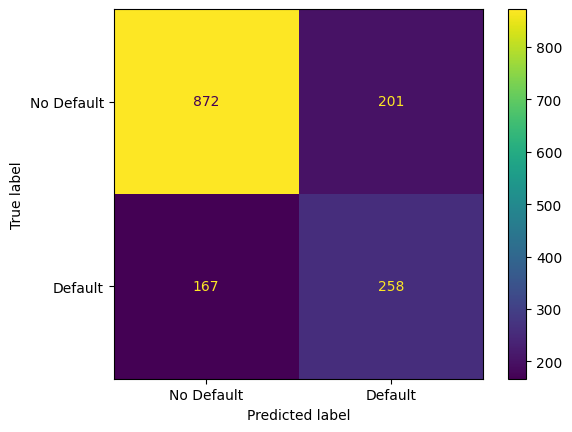

In [151]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='viridis');

### XGBoost

In [152]:
X_train_cv, X_val, y_train_cv, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=1,
    stratify=y_train
    )

In [153]:
from xgboost import XGBClassifier

model = XGBClassifier(
    grow_policy='lossguide',
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=10,
    )

model.fit(
    X_train_cv,
    y_train_cv,
    eval_set=[(X_val, y_val)],
    verbose=False
    )

print(f'La exactitud de este modelo con los datos de entrenamiento es: {model.score(X_train, y_train):.3f}')
print(f'La exactitud de este modelo con los datos de prueba es: {model.score(X_test, y_test):.3f}')

La exactitud de este modelo con los datos de entrenamiento es: 0.832
La exactitud de este modelo con los datos de prueba es: 0.811


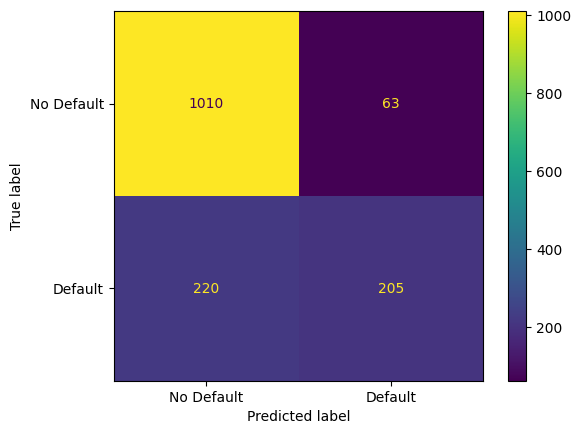

In [154]:
ConfusionMatrixDisplay.from_estimator(
    model, 
    X_test, 
    y_test, 
    display_labels=['No Default', 'Default']
    );

In [155]:
from scipy.stats import randint, uniform

dist = {'n_estimators':randint(1,500),
        'max_depth':randint(3,10),
        'learning_rate':loguniform(0.001,0.3),
        'subsample':uniform(0.5,0.5),
        'colsample_bytree':uniform(0.5,0.5),
        'min_child_weight':randint(5,10),
        'gamma':uniform(0,5),
        'reg_alpha':loguniform(1e-3,10),
        'reg_lambda':loguniform(1e-3,10),
        'scale_pos_weight':uniform(1,10), #Balanceo de clases
        'max_delta_step':randint(0,10),
        }

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=dist,
    random_state=1,
    n_iter=20,
    scoring='f1'
    )

random_search.fit(
    X_train_cv,
    y_train_cv,
    eval_set=[(X_val, y_val)],
    verbose=False
    )

print(f"Best F1 score: {random_search.best_score_:.3f}\n")
print("Best hyperparameters:")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

print(f'Train score: {random_search.score(X_train, y_train):.3f}')
print(f'Test score: {random_search.score(X_test, y_test):.3f}')

y_pred = random_search.predict(X_test)
print(classification_report(
    y_test, 
    y_pred,
    target_names=['No Default', 'Default']
    ))

Best F1 score: 0.631

Best hyperparameters:
colsample_bytree: 0.9035525978093896
gamma: 1.9393032203208587
learning_rate: 0.1377519902449959
max_delta_step: 0
max_depth: 8
min_child_weight: 9
n_estimators: 56
reg_alpha: 0.003514154914958963
reg_lambda: 0.0017364838879731566
scale_pos_weight: 2.2134345574073735
subsample: 0.5222759392723808
Train score: 0.691
Test score: 0.617
              precision    recall  f1-score   support

  No Default       0.85      0.83      0.84      1073
     Default       0.60      0.64      0.62       425

    accuracy                           0.78      1498
   macro avg       0.73      0.73      0.73      1498
weighted avg       0.78      0.78      0.78      1498



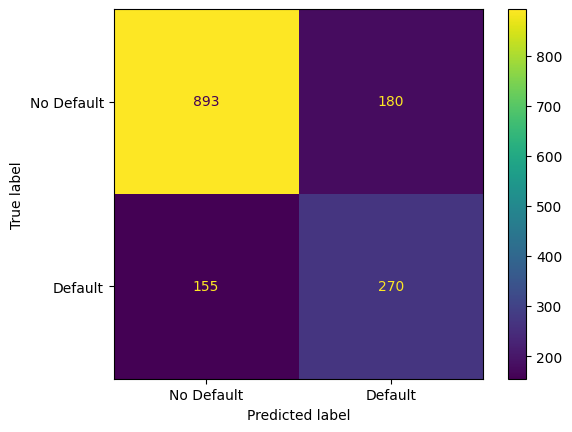

In [156]:
ConfusionMatrixDisplay.from_estimator(
    random_search, 
    X_test, 
    y_test, 
    display_labels=['No Default', 'Default']
    );

# Créditos negados versus créditos acordados

In [164]:
file_neg = data_dir / "Información créditos negados.xlsx"
file_apr = data_dir / "DOC-20250319-WA0027..xlsx"

neg = pd.read_excel(file_neg)
apr = pd.read_excel(file_apr, sheet_name='Datos')
apr['NIT_clean'] = pd.to_numeric(apr['NIT'], errors='coerce')

print(f"Créditos aprobados: {len(apr):,} registros | {apr['NIT_clean'].nunique():,} cédulas unicas")
print(f"Créditos negados: {len(neg):,} registros | {neg['NUMEROIDENTIFICACION'].nunique():,} cédulas unicas")

neg_ids = set(neg['NUMEROIDENTIFICACION'].unique())
apr_ids = set(apr['NIT_clean'].dropna().unique())
both_ids = neg_ids & apr_ids
    
print(f"Cédulas SOLO en negados: {len(neg_ids - apr_ids):,}")
print(f"Cédulas SOLO en aprobados: {len(apr_ids - neg_ids):,}")
print(f"Cédulas en AMBAS BASES: {len(both_ids):,}")
print(f"\nTasa de conversion negado -> aprobado: {len(both_ids)/len(neg_ids)*100:.1f}%")

Créditos aprobados: 21,502 registros | 17,917 cédulas unicas
Créditos negados: 3,978 registros | 3,559 cédulas unicas
Cédulas SOLO en negados: 2,269
Cédulas SOLO en aprobados: 16,627
Cédulas en AMBAS BASES: 1,290

Tasa de conversion negado -> aprobado: 36.2%


In [165]:
neg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3978 entries, 0 to 3977
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   NUMEROIDENTIFICACION    3978 non-null   int64         
 1   Causal                  3978 non-null   object        
 2   Estado                  3978 non-null   object        
 3   FECHAINGRESO            3978 non-null   datetime64[ns]
 4   FECHANACIMIENTO         3965 non-null   datetime64[ns]
 5   EDAD                    3965 non-null   float64       
 6   CODCIUDADNACIMIENTO     3965 non-null   float64       
 7   CIUDADNACIMIENTO        3926 non-null   object        
 8   DEPARTAMENTONACIMIENTO  3965 non-null   object        
 9   CODCIUDADRESIDENCIA     3972 non-null   float64       
 10  CIUDADRESIDENCIA        3972 non-null   object        
 11  DEPARTAMENTORESIDENCIA  3972 non-null   object        
 12  CODCIUDADLABORAL        3524 non-null   float64 

In [203]:
df_neg = neg[['Estado', 'EDAD', 'GENERO', 'ESTRATO', 'TOTALINGRESOS', 'EGRESOS']]
df_neg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3978 entries, 0 to 3977
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Estado         3978 non-null   object 
 1   EDAD           3965 non-null   float64
 2   GENERO         3978 non-null   object 
 3   ESTRATO        3965 non-null   float64
 4   TOTALINGRESOS  3965 non-null   float64
 5   EGRESOS        3965 non-null   float64
dtypes: float64(4), object(2)
memory usage: 186.6+ KB


In [204]:
df_neg = df_neg.rename(columns={
    'EDAD': 'Edad',
    'ESTRATO': 'Estrato',
    'TOTALINGRESOS': 'Total Ingresos',
    'EGRESOS': 'Total Egresos',
    'GENERO': 'Genero'
})

df_neg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3978 entries, 0 to 3977
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Estado          3978 non-null   object 
 1   Edad            3965 non-null   float64
 2   Genero          3978 non-null   object 
 3   Estrato         3965 non-null   float64
 4   Total Ingresos  3965 non-null   float64
 5   Total Egresos   3965 non-null   float64
dtypes: float64(4), object(2)
memory usage: 186.6+ KB


In [205]:
df_neg['Genero'].value_counts()

Genero
Masculino    2007
Femenino     1971
Name: count, dtype: int64

In [206]:
df_neg = df_neg.dropna()
df_neg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3965 entries, 0 to 3977
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Estado          3965 non-null   object 
 1   Edad            3965 non-null   float64
 2   Genero          3965 non-null   object 
 3   Estrato         3965 non-null   float64
 4   Total Ingresos  3965 non-null   float64
 5   Total Egresos   3965 non-null   float64
dtypes: float64(4), object(2)
memory usage: 216.8+ KB


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12856 entries, 0 to 12860
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cartera               12856 non-null  object 
 1   default               12856 non-null  float64
 2   puntaje_data          12856 non-null  float64
 3   intestrato            12856 non-null  float64
 4   edad                  12856 non-null  float64
 5   grupo_edad            12856 non-null  float64
 6   sexo                  12856 non-null  float64
 7   curtotalingresos      12856 non-null  float64
 8   curtotalegresos       12856 non-null  float64
 9   grupo_actividadeco    12856 non-null  float64
 10  dif_ingresos_egresos  12856 non-null  float64
 11  genero                12856 non-null  object 
 12  default_label         12856 non-null  object 
dtypes: float64(10), object(3)
memory usage: 1.4+ MB


In [208]:
df_apr = df[['cartera', 'intestrato', 'edad', 'genero','curtotalingresos', 'curtotalegresos']]
df_apr = df_apr.rename(columns={
    'cartera': 'Estado',
    'intestrato': 'Estrato',
    'edad': 'Edad',
    'genero': 'Genero',
    'curtotalingresos': 'Total Ingresos',
    'curtotalegresos': 'Total Egresos'
})

df_apr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12856 entries, 0 to 12860
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Estado          12856 non-null  object 
 1   Estrato         12856 non-null  float64
 2   Edad            12856 non-null  float64
 3   Genero          12856 non-null  object 
 4   Total Ingresos  12856 non-null  float64
 5   Total Egresos   12856 non-null  float64
dtypes: float64(4), object(2)
memory usage: 703.1+ KB


In [209]:
df_neg_apr = pd.concat([df_neg, df_apr], ignore_index=True)
df_neg_apr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16821 entries, 0 to 16820
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Estado          16821 non-null  object 
 1   Edad            16821 non-null  float64
 2   Genero          16821 non-null  object 
 3   Estrato         16821 non-null  float64
 4   Total Ingresos  16821 non-null  float64
 5   Total Egresos   16821 non-null  float64
dtypes: float64(4), object(2)
memory usage: 788.6+ KB


In [210]:
df_neg_apr.groupby('Estado')['Edad'].describe()

,count,mean,std,min,25%,50%,75%,max
Estado,,,,,,,,
Negado,3965.0,43.136696,13.371600,19.0,33.0,41.0,52.0,88.0
consumo_con_libranza,5368.0,39.738450,10.861072,19.0,31.0,39.0,48.0,78.0
consumo_sin_libranza,7488.0,41.717147,13.241401,19.0,31.0,39.0,50.0,90.0


In [211]:
df_neg_apr.groupby('Estado')['Total Ingresos'].describe()

,count,mean,std,min,25%,50%,75%,max
Estado,,,,,,,,
Negado,3965.0,1.186486e+07,5.248294e+08,0.0,1537400.00,2300000.0,3800000.0,3.305000e+10
consumo_con_libranza,5368.0,2.328562e+06,1.815815e+06,0.0,1400000.00,1827128.0,2585250.0,3.550000e+07
consumo_sin_libranza,7488.0,4.691447e+06,1.422817e+07,0.0,1330649.25,2150210.0,4000000.0,4.000000e+08


In [212]:
df_neg_apr.groupby('Estado')['Total Egresos'].describe()

,count,mean,std,min,25%,50%,75%,max
Estado,,,,,,,,
Negado,3965.0,1.726756e+06,2.294646e+07,0.0,400000.0,600000.0,1000000.0,1.000000e+09
consumo_con_libranza,5368.0,7.538975e+05,1.350346e+06,0.0,400000.0,537849.5,800000.0,6.000000e+07
consumo_sin_libranza,7488.0,1.259790e+06,1.748869e+07,0.0,400000.0,600000.0,1000000.0,1.501600e+09


In [214]:
pd.crosstab(
    df_neg_apr['Estado'], 
    df_neg_apr['Genero'], 
    normalize='index', 
    margins=True, 
    margins_name='Total'
    ).round(3) * 100

Genero,Femenino,Masculino
Estado,,
Negado,49.7,50.3
consumo_con_libranza,43.7,56.3
consumo_sin_libranza,48.6,51.4
Total,47.3,52.7


In [215]:
pd.crosstab(
    df_neg_apr['Estado'], 
    df_neg_apr['Estrato'], 
    normalize='index', 
    margins=True, 
    margins_name='Total'
    ).round(3) * 100

Estrato,0.0,1.0,2.0,3.0,4.0,5.0,6.0
Estado,,,,,,,
Negado,0.0,7.2,39.3,40.5,9.7,2.5,0.8
consumo_con_libranza,0.0,9.9,45.6,37.7,5.0,1.4,0.4
consumo_sin_libranza,0.0,6.8,35.2,42.8,10.0,3.6,1.5
Total,0.0,7.9,39.5,40.6,8.3,2.7,1.0


In [218]:
(df_neg_apr.pivot_table(
    index='Estado',
    columns='Estrato', 
    margins=True, 
    margins_name='Total',
    values='Edad',
    aggfunc='count'
)/len(df_neg_apr)).round(3) * 100

Estrato,0.0,1.0,2.0,3.0,4.0,5.0,6.0,Total
Estado,,,,,,,,
Negado,0.0,1.7,9.3,9.5,2.3,0.6,0.2,23.6
consumo_con_libranza,NaN,3.2,14.5,12.0,1.6,0.5,0.1,31.9
consumo_sin_libranza,NaN,3.0,15.7,19.1,4.4,1.6,0.7,44.5
Total,0.0,7.9,39.5,40.6,8.3,2.7,1.0,100.0


In [219]:
(df_neg_apr.pivot_table(
    index='Estado',
    columns='Estrato', 
    margins=True, 
    margins_name='Total',
    values='Total Ingresos',
    aggfunc='median'
)).round(3) * 100

Estrato,0.0,1.0,2.0,3.0,4.0,5.0,6.0,Total
Estado,,,,,,,,
Negado,150015000.0,167551350.0,190000000.0,262425000.0,417350000.0,676800000.0,7.000000e+08,230000000.0
consumo_con_libranza,NaN,153922400.0,169000000.0,200229200.0,309720700.0,590592300.0,1.089452e+09,182712800.0
consumo_sin_libranza,NaN,135200100.0,168937700.0,244779700.0,450000000.0,659896300.0,1.330000e+09,215021000.0
Total,150015000.0,151800000.0,173800000.0,230000000.0,404147500.0,650000000.0,1.109321e+09,203223100.0
